In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Допоміжні функції

In [25]:
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MSE": round(mse, 4),
        "RMSE": round(np.sqrt(mse), 4),
        "MAE": round(mean_absolute_error(y_true, y_pred), 4),
        "R2": round(r2_score(y_true, y_pred), 4)
    }


def show_metrics(title, metrics):
    print(title)
    for key, value in metrics.items():
        print(f"{key}: {value}")


def add_free_term(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])


def show_train_test_plot(y_train, y_train_pred, y_test, y_test_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_train, y_train_pred)
    axes[0].set_xlabel("Реальні значення")
    axes[0].set_ylabel("Прогнозовані значення")
    axes[0].set_title("Train")
    axes[0].grid()

    axes[1].scatter(y_test, y_test_pred)
    axes[1].set_xlabel("Реальні значення")
    axes[1].set_ylabel("Прогнозовані значення")
    axes[1].set_title("Test")
    axes[1].grid()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_optimization_plot(history, y_test, y_test_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history)
    axes[0].set_xlabel("Ітерація")
    axes[0].set_ylabel("Найкраще значення функції втрат")
    axes[0].set_title("Збіжність")
    axes[0].grid()

    axes[1].scatter(y_test, y_test_pred)
    axes[1].set_xlabel("Реальні значення")
    axes[1].set_ylabel("Прогнозовані значення")
    axes[1].set_title("Прогноз Test")
    axes[1].grid()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_result_table(results):
    print("+--------------------------------------------+--------+--------+--------+--------+")
    print("| Метод                                      |  MSE   |  RMSE  |  MAE   |   R2   |")
    print("+--------------------------------------------+--------+--------+--------+--------+")

    for row in results:
        print(
            f"| {row['Метод']:<42} | "
            f"{row['MSE']:^6} | "
            f"{row['RMSE']:^6} | "
            f"{row['MAE']:^6} | "
            f"{row['R2']:^6} |"
        )

    print("+--------------------------------------------+--------+--------+--------+--------+")

### Завантаження даних Var3

In [26]:
file_path = "TestRegData.xlsx"
sheet_name = "Var3"

df = pd.read_excel(file_path, sheet_name=sheet_name)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("Перші рядки файлу TestRegData.xlsx:")
print(df.head())

print("\nРозмір X:", X.shape)
print("Розмір y:", y.shape)

Перші рядки файлу TestRegData.xlsx:
         x1        x2        x3        x4        x5        x6        x7  \
0  0.099026  0.219040  0.936582  0.428746  0.061932  0.159037  0.009043   
1  0.487961  0.270624  0.012128  0.288347  0.742457  0.931850  0.650918   
2  0.997343  0.260487  0.151397  0.500601  0.936200  0.519761  0.295196   
3  0.198241  0.167183  0.531118  0.693859  0.412567  0.305804  0.239924   
4  0.722969  0.415599  0.381303  0.448592  0.805672  0.671806  0.569409   

         x8        x9       x10       x11       x12       x13       x14  \
0  0.553300  0.630543  0.894881  0.708217  0.434499  0.264107  0.269809   
1  0.463327  0.904402  0.869535  0.634963  0.494952  0.672707  0.469461   
2  0.386039  0.821953  0.414546  0.485801  0.367568  0.069419  0.326908   
3  0.608115  0.255824  0.677312  0.169737  0.650819  0.669280  0.971985   
4  0.596595  0.704909  0.629438  0.586956  0.309392  0.823706  0.312609   

           y  
0   2.956384  
1   6.263171  
2   8.253084  
3 

### Розбиття даних і масштабування

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_aug = add_free_term(X_train_scaled)
X_test_aug = add_free_term(X_test_scaled)

n_params = X_train_aug.shape[1]

### Ridge / L2 аналітично

Коефіцієнти Ridge:
[ 9.9027e+00  1.0857e+00 -1.1286e+00  1.1609e+00  1.1719e+00 -1.0000e-04
  1.1244e+00  1.1687e+00 -6.0560e-01 -1.4567e+00 -1.3835e+00 -8.7100e-01
  1.1369e+00  2.9510e-01  1.1799e+00]

Ridge Train:
MSE: 0.0009
RMSE: 0.0297
MAE: 0.0254
R2: 0.9999

Ridge Test:
MSE: 0.001
RMSE: 0.0309
MAE: 0.0268
R2: 0.9999


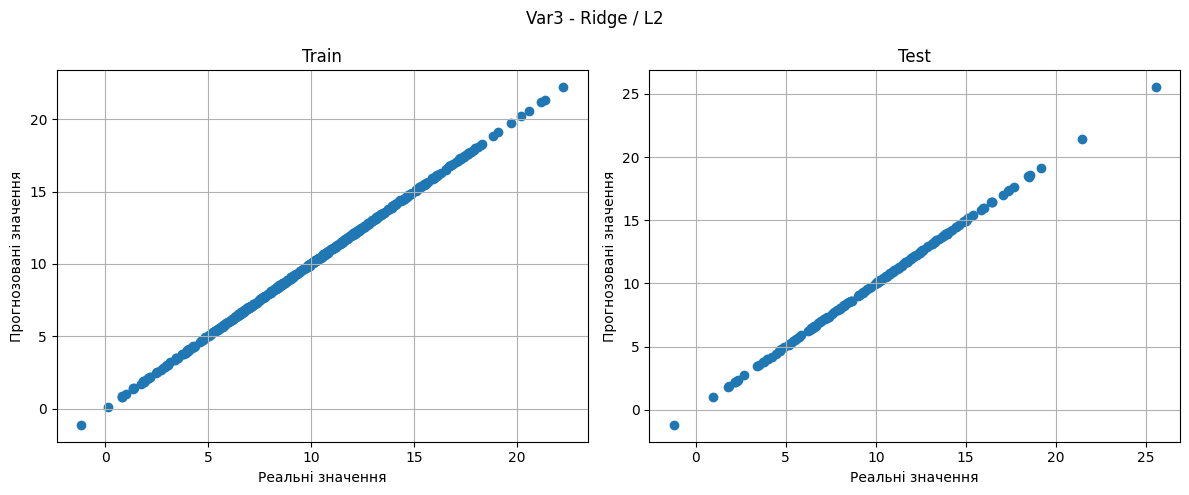

In [28]:
def ridge_solution(X, y, gamma):
    I = np.eye(X.shape[1])
    I[0, 0] = 0

    left_part = np.dot(X.T, X) + gamma * I
    right_part = np.dot(X.T, y)

    coefficients = np.linalg.solve(left_part, right_part)

    return coefficients


def ridge_predict(X, coefficients):
    return np.dot(X, coefficients)


gamma = 1.0

ridge_coefficients = ridge_solution(
    X_train_aug,
    y_train,
    gamma
)

y_train_pred_ridge = ridge_predict(X_train_aug, ridge_coefficients)
y_test_pred_ridge = ridge_predict(X_test_aug, ridge_coefficients)

ridge_train_metrics = get_metrics(y_train, y_train_pred_ridge)
ridge_test_metrics = get_metrics(y_test, y_test_pred_ridge)

print("Коефіцієнти Ridge:")
print(np.round(ridge_coefficients, 4))

show_metrics("\nRidge Train:", ridge_train_metrics)
show_metrics("\nRidge Test:", ridge_test_metrics)

show_train_test_plot(
    y_train,
    y_train_pred_ridge,
    y_test,
    y_test_pred_ridge,
    "Var3 - Ridge / L2"
)

### Аналіз параметра gamma для Ridge

Вплив gamma для Ridge:
     gamma  Train MSE  Test MSE  Train R2  Test R2
0    0.001     0.0008    0.0008    0.9999   1.0000
1    0.010     0.0008    0.0008    0.9999   1.0000
2    0.100     0.0008    0.0008    0.9999   1.0000
3    1.000     0.0009    0.0010    0.9999   0.9999
4   10.000     0.0058    0.0071    0.9996   0.9996
5  100.000     0.3688    0.4203    0.9776   0.9767


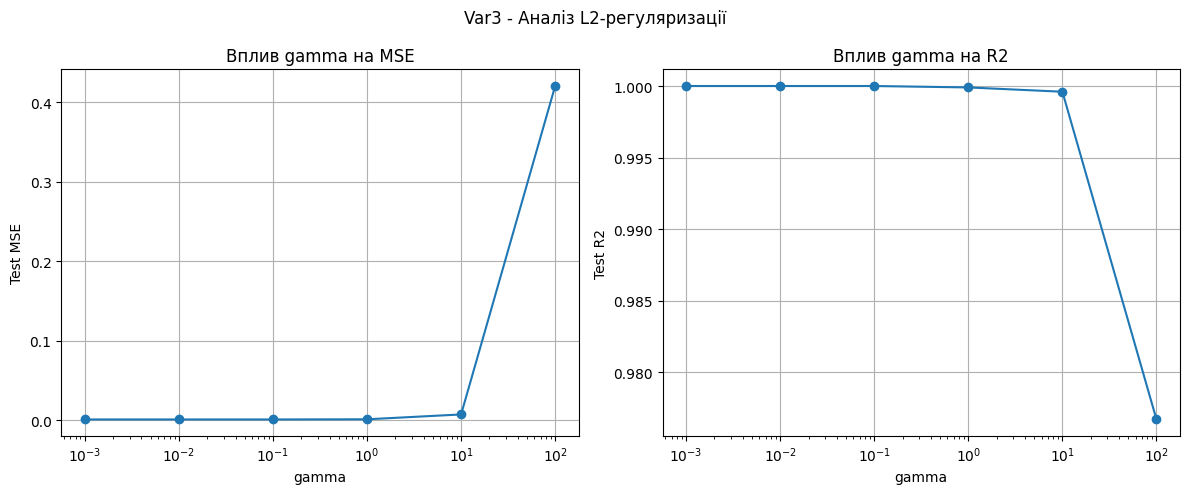

In [29]:
gammas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_gamma_results = []

for gamma in gammas:
    coefficients = ridge_solution(X_train_aug, y_train, gamma)

    y_train_pred = ridge_predict(X_train_aug, coefficients)
    y_test_pred = ridge_predict(X_test_aug, coefficients)

    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)

    ridge_gamma_results.append({
        "gamma": gamma,
        "Train MSE": train_metrics["MSE"],
        "Test MSE": test_metrics["MSE"],
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"]
    })

ridge_gamma_df = pd.DataFrame(ridge_gamma_results)

print("Вплив gamma для Ridge:")
print(ridge_gamma_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ridge_gamma_df["gamma"], ridge_gamma_df["Test MSE"], marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("Test MSE")
axes[0].set_title("Вплив gamma на MSE")
axes[0].grid()

axes[1].plot(ridge_gamma_df["gamma"], ridge_gamma_df["Test R2"], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("Test R2")
axes[1].set_title("Вплив gamma на R2")
axes[1].grid()

fig.suptitle("Var3 - Аналіз L2-регуляризації")
plt.tight_layout()
plt.show()

### Lasso / L1

Результати Lasso:
    alpha  Train MSE  Test MSE  Train R2  Test R2  Zero coefficients
0   0.001     0.0008    0.0009    0.9999   1.0000                  1
1   0.010     0.0021    0.0026    0.9999   0.9999                  1
2   0.100     0.1328    0.1508    0.9919   0.9916                  1
3   1.000    10.8637   12.3677    0.3404   0.3146                  3
4  10.000    16.4695   18.0731    0.0000  -0.0015                 14

Найкраще alpha: 0.001

Коефіцієнти Lasso:
[ 1.08679892 -1.1298416   1.16185516  1.17286216 -0.          1.12541452
  1.16975579 -0.6059862  -1.45815646 -1.38489705 -0.87118182  1.13796008
  0.29461431  1.18130449]

Кількість нульових коефіцієнтів: 1


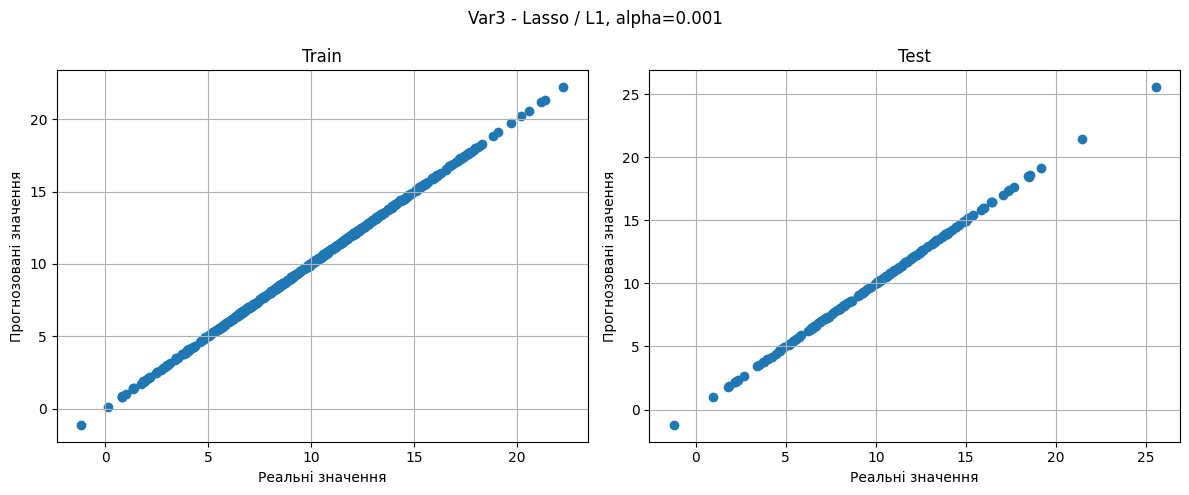

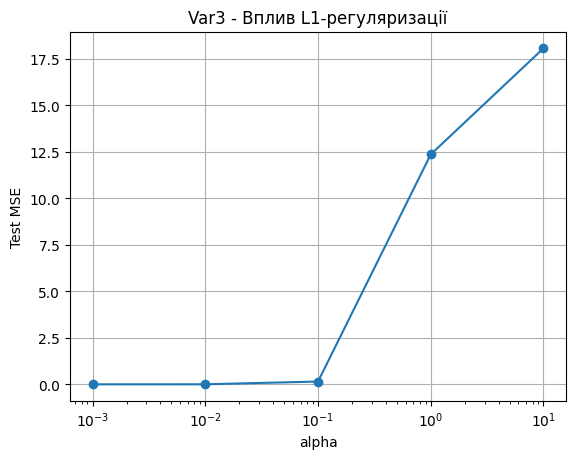

In [30]:
alphas = [0.001, 0.01, 0.1, 1, 10]

lasso_results = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)

    lasso_results.append({
        "alpha": alpha,
        "Train MSE": train_metrics["MSE"],
        "Test MSE": test_metrics["MSE"],
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"],
        "Zero coefficients": np.sum(model.coef_ == 0)
    })

lasso_results_df = pd.DataFrame(lasso_results)

print("Результати Lasso:")
print(lasso_results_df)

best_alpha = lasso_results_df.loc[
    lasso_results_df["Test MSE"].idxmin(),
    "alpha"
]

best_lasso = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
best_lasso.fit(X_train_scaled, y_train)

y_train_pred_lasso = best_lasso.predict(X_train_scaled)
y_test_pred_lasso = best_lasso.predict(X_test_scaled)

lasso_train_metrics = get_metrics(y_train, y_train_pred_lasso)
lasso_test_metrics = get_metrics(y_test, y_test_pred_lasso)

print("\nНайкраще alpha:", best_alpha)
print("\nКоефіцієнти Lasso:")
print(best_lasso.coef_)
print("\nКількість нульових коефіцієнтів:", np.sum(best_lasso.coef_ == 0))

show_train_test_plot(
    y_train,
    y_train_pred_lasso,
    y_test,
    y_test_pred_lasso,
    f"Var3 - Lasso / L1, alpha={best_alpha}"
)

plt.figure()
plt.plot(lasso_results_df["alpha"], lasso_results_df["Test MSE"], marker="o")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Test MSE")
plt.title("Var3 - Вплив L1-регуляризації")
plt.grid()
plt.show()

### Elastic Net

Результати Elastic Net:
    alpha  l1_ratio  Train MSE  Test MSE  Train R2  Test R2  Zero coeffs
0   0.001       0.2     0.0008    0.0009    0.9999   1.0000            0
1   0.001       0.5     0.0008    0.0009    0.9999   1.0000            1
2   0.001       0.8     0.0008    0.0009    0.9999   1.0000            1
5   0.010       0.8     0.0022    0.0026    0.9999   0.9999            1
4   0.010       0.5     0.0022    0.0027    0.9999   0.9998            1
3   0.010       0.2     0.0023    0.0028    0.9999   0.9998            1
7   0.100       0.5     0.1278    0.1463    0.9922   0.9919            1
6   0.100       0.2     0.1277    0.1468    0.9922   0.9919            1
8   0.100       0.8     0.1300    0.1481    0.9921   0.9918            1
9   1.000       0.2     4.6062    5.1446    0.7203   0.7149            1
10  1.000       0.5     6.0287    6.7404    0.6339   0.6265            3
11  1.000       0.8     8.2611    9.3386    0.4984   0.4825            3


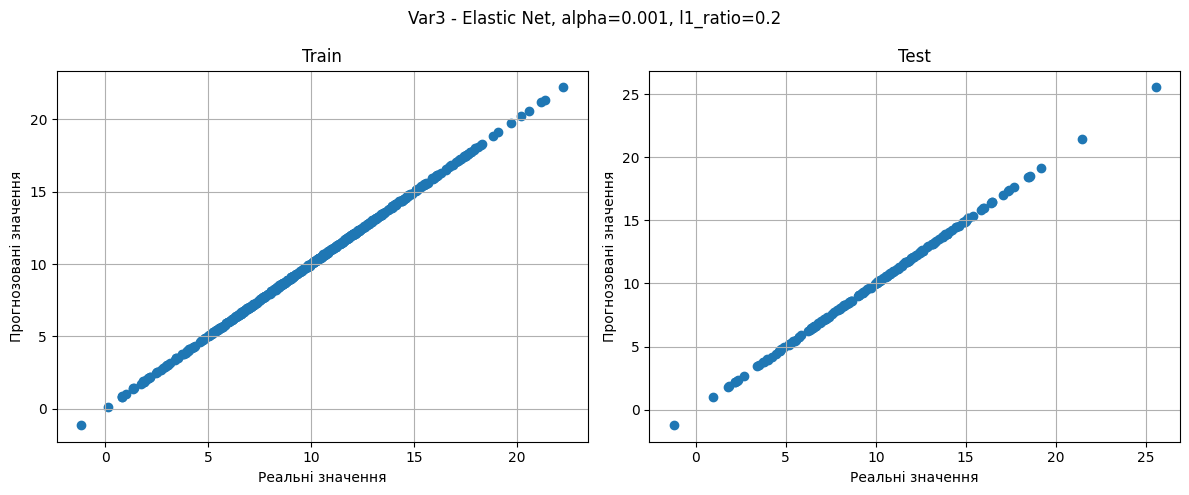

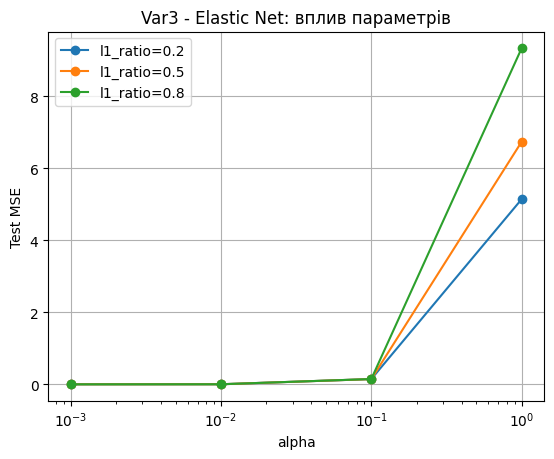

In [31]:
alphas = [0.001, 0.01, 0.1, 1]
l1_ratios = [0.2, 0.5, 0.8]

elastic_results = []

for alpha in alphas:
    for l1_ratio in l1_ratios:
        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=10000,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)

        train_metrics = get_metrics(y_train, y_train_pred)
        test_metrics = get_metrics(y_test, y_test_pred)

        elastic_results.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "Train MSE": train_metrics["MSE"],
            "Test MSE": test_metrics["MSE"],
            "Train R2": train_metrics["R2"],
            "Test R2": test_metrics["R2"],
            "Zero coeffs": np.sum(model.coef_ == 0)
        })

elastic_df = pd.DataFrame(elastic_results)

print("Результати Elastic Net:")
print(elastic_df.sort_values(by="Test MSE"))

best_elastic_row = elastic_df.loc[elastic_df["Test MSE"].idxmin()]

best_elastic_alpha = best_elastic_row["alpha"]
best_elastic_l1_ratio = best_elastic_row["l1_ratio"]

best_elastic = ElasticNet(
    alpha=best_elastic_alpha,
    l1_ratio=best_elastic_l1_ratio,
    max_iter=10000,
    random_state=42
)

best_elastic.fit(X_train_scaled, y_train)

y_train_pred_elastic = best_elastic.predict(X_train_scaled)
y_test_pred_elastic = best_elastic.predict(X_test_scaled)

elastic_train_metrics = get_metrics(y_train, y_train_pred_elastic)
elastic_test_metrics = get_metrics(y_test, y_test_pred_elastic)

show_train_test_plot(
    y_train,
    y_train_pred_elastic,
    y_test,
    y_test_pred_elastic,
    f"Var3 - Elastic Net, alpha={best_elastic_alpha}, l1_ratio={best_elastic_l1_ratio}"
)

plt.figure()

for ratio in l1_ratios:
    subset = elastic_df[elastic_df["l1_ratio"] == ratio]
    plt.plot(subset["alpha"], subset["Test MSE"], marker="o", label=f"l1_ratio={ratio}")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Test MSE")
plt.title("Var3 - Elastic Net: вплив параметрів")
plt.legend()
plt.grid()
plt.show()

### Функція втрат і межі оптимізації

In [32]:
def ridge_loss(coefficients, X, y, gamma):
    y_pred = np.dot(X, coefficients)
    error = y - y_pred

    sse = np.sum(error ** 2)
    penalty = gamma * np.sum(coefficients[1:] ** 2)

    return sse + penalty


def get_bounds(coefficients, margin=5):
    bounds = []

    for coefficient in coefficients:
        bounds.append((coefficient - margin, coefficient + margin))

    return np.array(bounds)


optimization_bounds = get_bounds(
    ridge_coefficients,
    margin=5
)


### Differential Evolution для Ridge

Коефіцієнти Ridge через DE:
[ 9.9027  0.9033 -0.9352  1.0005  1.0113  0.0246  0.9659  1.001  -0.4743
 -1.2511 -1.1936 -0.7683  0.9654  0.2426  0.9692]

DE Ridge Train:
MSE: 0.3688
RMSE: 0.6073
MAE: 0.4854
R2: 0.9776

DE Ridge Test:
MSE: 0.4203
RMSE: 0.6483
MAE: 0.5168
R2: 0.9767


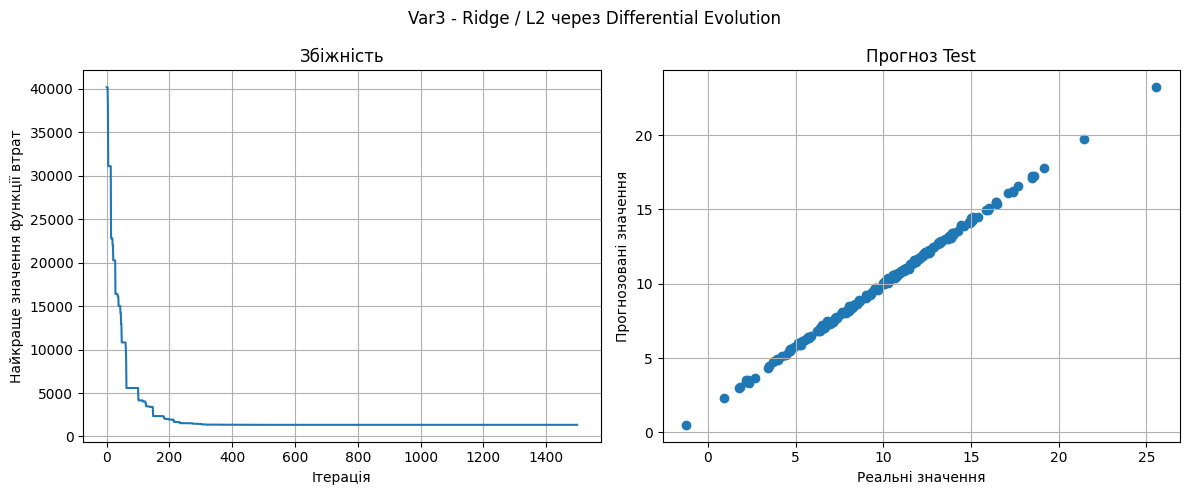

In [33]:
def ridge_de(
    X, y,
    gamma,
    bounds,
    pop_size=100,
    n_iter=1500,
    F=0.7,
    CR=0.9,
    random_state=42
):
    np.random.seed(random_state)

    n_params = X.shape[1]

    low = bounds[:, 0]
    high = bounds[:, 1]

    population = np.random.uniform(low, high, size=(pop_size, n_params))

    fitness = np.array([
        ridge_loss(individual, X, y, gamma)
        for individual in population
    ])

    best_idx = np.argmin(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]

    history = []

    for iteration in range(n_iter):
        for i in range(pop_size):
            indices = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(indices, 3, replace=False)

            mutant = population[r1] + F * (population[r2] - population[r3])
            mutant = np.clip(mutant, low, high)

            crossover_mask = np.random.rand(n_params) < CR

            if not np.any(crossover_mask):
                crossover_mask[np.random.randint(0, n_params)] = True

            trial = np.where(crossover_mask, mutant, population[i])
            trial_fitness = ridge_loss(trial, X, y, gamma)

            if trial_fitness < fitness[i]:
                population[i] = trial
                fitness[i] = trial_fitness

        best_idx = np.argmin(fitness)

        if fitness[best_idx] < best_fitness:
            best_fitness = fitness[best_idx]
            best_solution = population[best_idx].copy()

        history.append(best_fitness)

    return best_solution, history


de_coefficients, de_history = ridge_de(
    X_train_aug,
    y_train,
    gamma,
    optimization_bounds
)

y_train_pred_de = ridge_predict(X_train_aug, de_coefficients)
y_test_pred_de = ridge_predict(X_test_aug, de_coefficients)

de_train_metrics = get_metrics(y_train, y_train_pred_de)
de_test_metrics = get_metrics(y_test, y_test_pred_de)

print("Коефіцієнти Ridge через DE:")
print(np.round(de_coefficients, 4))

show_metrics("\nDE Ridge Train:", de_train_metrics)
show_metrics("\nDE Ridge Test:", de_test_metrics)

show_optimization_plot(
    de_history,
    y_test,
    y_test_pred_de,
    "Var3 - Ridge / L2 через Differential Evolution"
)

### PSO для Ridge

Коефіцієнти Ridge через PSO:
[ 9.9027  0.9033 -0.9352  1.0005  1.0113  0.0246  0.9659  1.001  -0.4743
 -1.2511 -1.1936 -0.7683  0.9654  0.2426  0.9692]

PSO Ridge Train:
MSE: 0.3688
RMSE: 0.6073
MAE: 0.4854
R2: 0.9776

PSO Ridge Test:
MSE: 0.4203
RMSE: 0.6483
MAE: 0.5168
R2: 0.9767


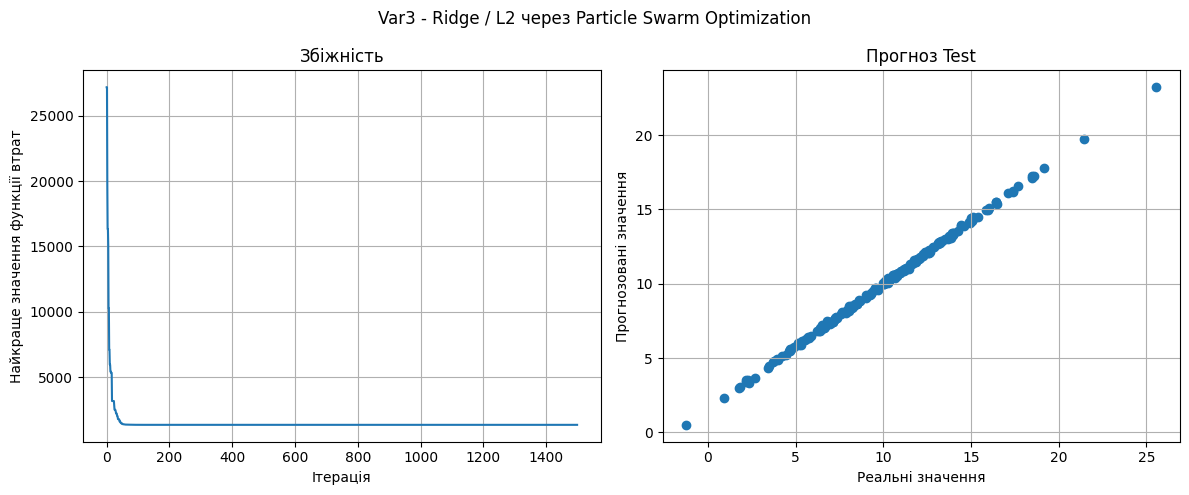

In [34]:
def ridge_pso(
    X, y,
    gamma,
    bounds,
    swarm_size=100,
    n_iter=1500,
    w=0.7,
    c1=1.7,
    c2=1.7,
    random_state=42
):
    np.random.seed(random_state)

    n_params = X.shape[1]

    low = bounds[:, 0]
    high = bounds[:, 1]

    positions = np.random.uniform(low, high, size=(swarm_size, n_params))
    velocities = np.random.uniform(-0.5, 0.5, size=(swarm_size, n_params))

    personal_best_positions = positions.copy()
    personal_best_scores = np.array([
        ridge_loss(position, X, y, gamma)
        for position in positions
    ])

    global_best_idx = np.argmin(personal_best_scores)
    global_best_position = personal_best_positions[global_best_idx].copy()
    global_best_score = personal_best_scores[global_best_idx]

    history = []

    for iteration in range(n_iter):
        for i in range(swarm_size):
            r1 = np.random.rand(n_params)
            r2 = np.random.rand(n_params)

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (personal_best_positions[i] - positions[i])
                + c2 * r2 * (global_best_position - positions[i])
            )

            positions[i] = positions[i] + velocities[i]
            positions[i] = np.clip(positions[i], low, high)

            score = ridge_loss(positions[i], X, y, gamma)

            if score < personal_best_scores[i]:
                personal_best_scores[i] = score
                personal_best_positions[i] = positions[i].copy()

        global_best_idx = np.argmin(personal_best_scores)

        if personal_best_scores[global_best_idx] < global_best_score:
            global_best_score = personal_best_scores[global_best_idx]
            global_best_position = personal_best_positions[global_best_idx].copy()

        history.append(global_best_score)

    return global_best_position, history


pso_coefficients, pso_history = ridge_pso(
    X_train_aug,
    y_train,
    gamma,
    optimization_bounds
)

y_train_pred_pso = ridge_predict(X_train_aug, pso_coefficients)
y_test_pred_pso = ridge_predict(X_test_aug, pso_coefficients)

pso_train_metrics = get_metrics(y_train, y_train_pred_pso)
pso_test_metrics = get_metrics(y_test, y_test_pred_pso)

print("Коефіцієнти Ridge через PSO:")
print(np.round(pso_coefficients, 4))

show_metrics("\nPSO Ridge Train:", pso_train_metrics)
show_metrics("\nPSO Ridge Test:", pso_test_metrics)

show_optimization_plot(
    pso_history,
    y_test,
    y_test_pred_pso,
    "Var3 - Ridge / L2 через Particle Swarm Optimization"
)

### Порівняння збіжності DE та PSO

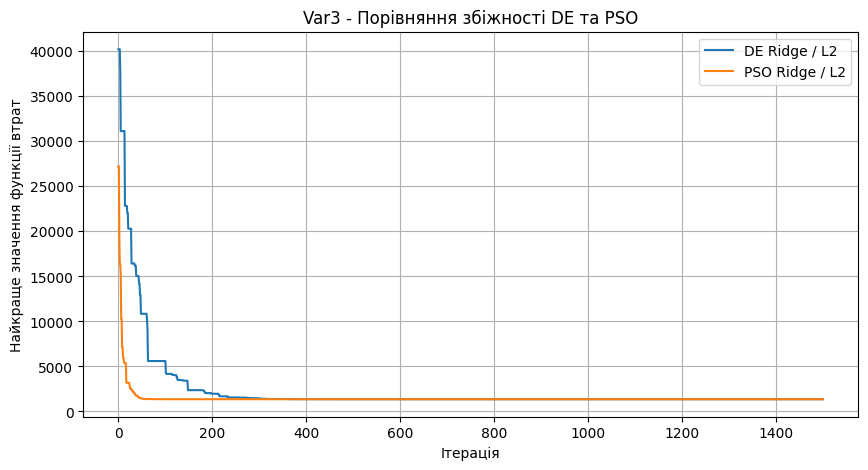

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(de_history, label="DE Ridge / L2")
plt.plot(pso_history, label="PSO Ridge / L2")
plt.xlabel("Ітерація")
plt.ylabel("Найкраще значення функції втрат")
plt.title("Var3 - Порівняння збіжності DE та PSO")
plt.legend()
plt.grid()
plt.show()

### Фінальне порівняння методів для Var3

In [36]:
final_results = [
    {"Метод": "Ridge / L2 аналітично", **ridge_test_metrics},
    {"Метод": f"Lasso / L1 (a={best_alpha})", **lasso_test_metrics},
    {"Метод": f"Elastic Net (a={best_elastic_alpha}, l1={best_elastic_l1_ratio})", **elastic_test_metrics},
    {"Метод": "DE Ridge / L2", **de_test_metrics},
    {"Метод": "PSO Ridge / L2", **pso_test_metrics}
]

print("Фінальне порівняння методів:")
show_result_table(final_results)

Фінальне порівняння методів:
+--------------------------------------------+--------+--------+--------+--------+
| Метод                                      |  MSE   |  RMSE  |  MAE   |   R2   |
+--------------------------------------------+--------+--------+--------+--------+
| Ridge / L2 аналітично                      | 0.001  | 0.0309 | 0.0268 | 0.9999 |
| Lasso / L1 (a=0.001)                       | 0.0009 | 0.0296 | 0.0257 |  1.0   |
| Elastic Net (a=0.001, l1=0.2)              | 0.0009 | 0.0297 | 0.0259 |  1.0   |
| DE Ridge / L2                              | 0.4203 | 0.6483 | 0.5168 | 0.9767 |
| PSO Ridge / L2                             | 0.4203 | 0.6483 | 0.5168 | 0.9767 |
+--------------------------------------------+--------+--------+--------+--------+


### Boston Housing

#### 1.Завантаження даних

In [37]:
boston_file_path = "boston_housing.xlsx"

boston_df = pd.read_excel(boston_file_path)

print("Перші рядки boston_housing.xlsx:")
print(boston_df.head())

X_boston = boston_df.iloc[:, :-1].values
y_boston = boston_df.iloc[:, -1].values

print("\nРозмір X_boston:", X_boston.shape)
print("Розмір y_boston:", y_boston.shape)

Перші рядки boston_housing.xlsx:
         X1    X2        X3  X4        X5        X6        X7        X8  \
0  0.000000  0.18  0.067815   0  0.314815  0.577505  0.641607  0.269203   
1  0.000236  0.00  0.242302   0  0.172840  0.547998  0.782698  0.348962   
2  0.000236  0.00  0.242302   0  0.172840  0.694386  0.599382  0.348962   
3  0.000293  0.00  0.063050   0  0.150206  0.658555  0.441813  0.448545   
4  0.000705  0.00  0.063050   0  0.150206  0.687105  0.528321  0.448545   

         X9       X10  ...       X96       X97       X98       X99      X100  \
0  0.000000  0.208015  ...  0.059749  0.208015  0.018655  0.082503  0.287234   
1  0.043478  0.104962  ...  0.058064  0.104962  0.021462  0.306021  0.553191   
2  0.043478  0.104962  ...  0.058064  0.103885  0.006661  0.306021  0.547514   
3  0.086957  0.066794  ...  0.043345  0.066412  0.002230  0.421118  0.645222   
4  0.086957  0.066794  ...  0.043345  0.066794  0.006635  0.421118  0.648936   

       X101      X102      X103    

#### 2.Розбиття даних і масштабування

In [38]:
X_train_boston, X_test_boston, y_train_boston, y_test_boston = train_test_split(
    X_boston,
    y_boston,
    test_size=0.25,
    random_state=42
)

boston_scaler = StandardScaler()

X_train_boston_scaled = boston_scaler.fit_transform(X_train_boston)
X_test_boston_scaled = boston_scaler.transform(X_test_boston)

X_train_boston_aug = add_free_term(X_train_boston_scaled)
X_test_boston_aug = add_free_term(X_test_boston_scaled)

#### 3.Аналіз gamma

In [39]:
gammas_boston = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_gamma_results_boston = []

for gamma_value in gammas_boston:
    coefficients = ridge_solution(
        X_train_boston_aug,
        y_train_boston,
        gamma_value
    )

    y_train_pred = ridge_predict(X_train_boston_aug, coefficients)
    y_test_pred = ridge_predict(X_test_boston_aug, coefficients)

    train_metrics = get_metrics(y_train_boston, y_train_pred)
    test_metrics = get_metrics(y_test_boston, y_test_pred)

    ridge_gamma_results_boston.append({
        "gamma": gamma_value,
        "Train MSE": train_metrics["MSE"],
        "Test MSE": test_metrics["MSE"],
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"]
    })

ridge_gamma_df_boston = pd.DataFrame(ridge_gamma_results_boston)

print("Вплив gamma для Boston Housing:")
print(ridge_gamma_df_boston.round(4))

best_gamma_boston = ridge_gamma_df_boston.loc[
    ridge_gamma_df_boston["Test MSE"].idxmin(),
    "gamma"
]

print("\nНайкраще gamma:", best_gamma_boston)

Вплив gamma для Boston Housing:
     gamma  Train MSE  Test MSE  Train R2  Test R2
0    0.001     4.9038   15.4530    0.9447   0.7793
1    0.010     4.9430   15.1239    0.9443   0.7840
2    0.100     5.1664   14.5480    0.9417   0.7923
3    1.000     5.9599   12.8513    0.9328   0.8165
4   10.000     8.0922   12.1831    0.9087   0.8260
5  100.000    13.7265   14.8514    0.8452   0.7879

Найкраще gamma: 10.0


#### 4.Фінальна Ridge-модель

In [40]:
gamma_boston = best_gamma_boston

ridge_coefficients_boston = ridge_solution(
    X_train_boston_aug,
    y_train_boston,
    gamma_boston
)

y_train_pred_ridge_boston = ridge_predict(
    X_train_boston_aug,
    ridge_coefficients_boston
)

y_test_pred_ridge_boston = ridge_predict(
    X_test_boston_aug,
    ridge_coefficients_boston
)

ridge_train_metrics_boston = get_metrics(
    y_train_boston,
    y_train_pred_ridge_boston
)

ridge_test_metrics_boston = get_metrics(
    y_test_boston,
    y_test_pred_ridge_boston
)

print("Коефіцієнти Ridge / L2 для Boston Housing:")
print(np.round(ridge_coefficients_boston, 4))


Коефіцієнти Ridge / L2 для Boston Housing:
[ 2.29079e+01 -1.59000e-01 -5.63800e-01  3.37800e-01  7.59700e-01
  4.02700e-01  2.40840e+00  2.54700e-01 -1.30520e+00  1.27650e+00
  4.06800e-01  6.97000e-02  5.20500e-01 -2.95600e-01  6.39700e-01
  8.30000e-02 -1.02900e-01  2.22740e+00 -4.23400e-01  3.51000e-02
 -2.86000e-01 -1.68500e-01 -2.76800e-01 -2.14600e-01 -2.14900e-01
 -1.98200e-01 -2.75000e-02  2.57800e-01 -2.79600e-01  1.98200e-01
  1.74300e-01  3.43800e-01  4.55000e-02 -1.58500e-01 -4.35000e-01
  8.33400e-01  9.07500e-01 -4.68100e-01 -7.41300e-01  5.88800e-01
  2.25300e-01  3.27200e-01 -9.53000e-02  3.70100e-01 -7.18500e-01
  5.98000e-01  7.60100e-01 -4.88700e-01  5.83600e-01 -1.39550e+00
  7.59700e-01 -1.76460e+00 -1.66350e+00  6.40700e-01 -2.24700e-01
 -4.47600e-01 -3.62900e-01 -7.07000e-02  9.88400e-01 -6.02600e-01
 -3.54400e-01 -8.48300e-01 -5.08800e-01  7.78000e-02  2.58000e-02
 -3.12000e-02 -5.98800e-01 -3.79700e-01  1.42400e-01  3.56210e+00
 -4.49100e-01  6.27300e-01 -1.493

In [41]:
show_metrics("\nBoston Ridge Train:", ridge_train_metrics_boston)
show_metrics("\nBoston Ridge Test:", ridge_test_metrics_boston)


Boston Ridge Train:
MSE: 8.0922
RMSE: 2.8447
MAE: 2.0755
R2: 0.9087

Boston Ridge Test:
MSE: 12.1831
RMSE: 3.4904
MAE: 2.2128
R2: 0.826


#### 5. Графіки

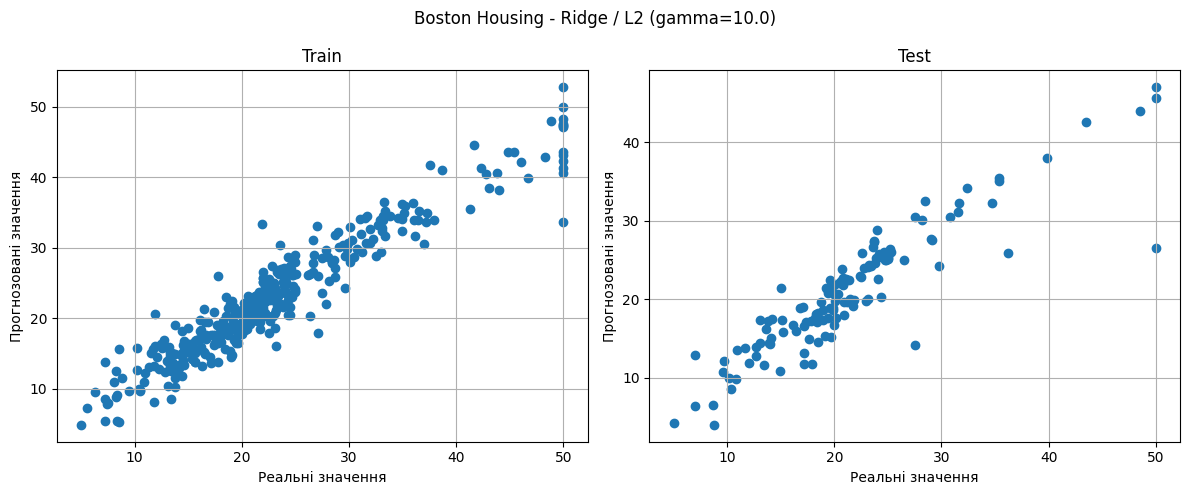

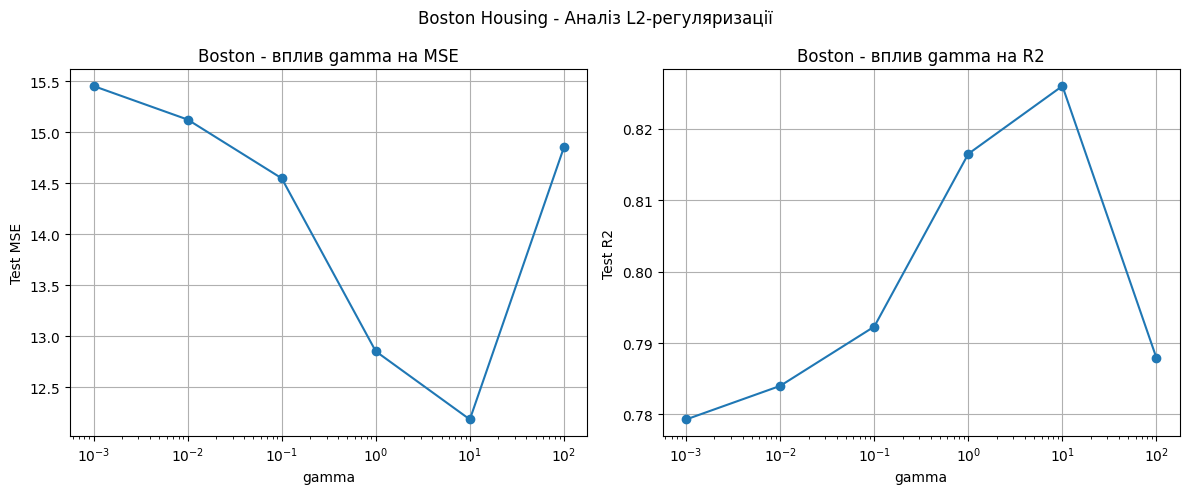

In [42]:
show_train_test_plot(
    y_train_boston,
    y_train_pred_ridge_boston,
    y_test_boston,
    y_test_pred_ridge_boston,
    f"Boston Housing - Ridge / L2 (gamma={gamma_boston})"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    ridge_gamma_df_boston["gamma"],
    ridge_gamma_df_boston["Test MSE"],
    marker="o"
)
axes[0].set_xscale("log")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("Test MSE")
axes[0].set_title("Boston - вплив gamma на MSE")
axes[0].grid()

axes[1].plot(
    ridge_gamma_df_boston["gamma"],
    ridge_gamma_df_boston["Test R2"],
    marker="o"
)
axes[1].set_xscale("log")
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("Test R2")
axes[1].set_title("Boston - вплив gamma на R2")
axes[1].grid()

fig.suptitle("Boston Housing - Аналіз L2-регуляризації")
plt.tight_layout()
plt.show()

In [43]:
boston_final_results = [
    {"Метод": f"Ridge / L2 (gamma={gamma_boston})", **ridge_test_metrics_boston}
]

print("Фінальний результат для Boston Housing:")
show_result_table(boston_final_results)

Фінальний результат для Boston Housing:
+--------------------------------------------+--------+--------+--------+--------+
| Метод                                      |  MSE   |  RMSE  |  MAE   |   R2   |
+--------------------------------------------+--------+--------+--------+--------+
| Ridge / L2 (gamma=10.0)                    | 12.1831 | 3.4904 | 2.2128 | 0.826  |
+--------------------------------------------+--------+--------+--------+--------+
